# <span style="color:#1E2D6B">PA-BI E-Commerce</span>  
## <span style="color:#E669B9">Machine Learning</span>

---

### <span style="color:#1E2D6B">Introduction</span>
Welcome to the <span style="color:#E669B9">Machine Learning</span> section.

---

### <span style="color:#1E2D6B">Applications</span>
- <span style="color:#E669B9">Product Recommendation</span>  
- <span style="color:#E669B9">Customer Segmentation</span>  

## <span style="color:#E669B9">Regression Task</span>

---

### <span style="color:#1E2D6B">Objective</span>
The main objective of this part is to build a regression model  
that predicts the **monetary value of the next order** placed by a customer:

- <span style="color:#E669B9">Target variable</span> : `Montant_de_la_commande` (order amount in TND)  
- <span style="color:#E669B9">Granularity</span> : One row per transaction  
- <span style="color:#E669B9">Type</span> : Supervised regression (continuous numerical output)  

---

### <span style="color:#1E2D6B">Approach</span>
We will use machine learning regression techniques to analyze transaction data  
and identify patterns that influence the order amount.

The models will be trained on features extracted from the Data Warehouse:

- <span style="color:#E669B9">Transaction features</span> : quantity, unit price, discount, delivery cost, promo code  
- <span style="color:#E669B9">Product features</span> : catalogue price, promotion status, product category  
- <span style="color:#E669B9">Client features</span> : client type (B2B / B2C), city, sales channel  
- <span style="color:#E669B9">Temporal features</span> : month, quarter, semester, high season indicator  

---

### <span style="color:#1E2D6B">Models Used</span>
At least two models will be implemented and compared:

- <span style="color:#E669B9">Random Forest Regressor</span> — robust non-linear ensemble model  
- <span style="color:#E669B9">Ridge Regression</span>

---

### <span style="color:#1E2D6B">Evaluation Metrics</span>
Models will be compared using the following metrics:

- <span style="color:#E669B9">MAE</span> — Mean Absolute Error (average error in TND, easy to interpret)  
- <span style="color:#E669B9">RMSE</span> — Root Mean Squared Error (penalizes large errors)  
- <span style="color:#E669B9">R²</span> — Coefficient of determination (% of variance explained by the model)  

---

### <span style="color:#1E2D6B">Expected Outcome</span>
A predictive model capable of helping the business:

- Anticipate revenue and improve financial planning  
- Personalize commercial offers based on predicted order value  
- Identify high-value transactions and prioritize B2B relationships  
- Optimize pricing and discount strategies for artisanal products

# Dependencies Instalation

In [1]:
pip install pyodbc sqlalchemy pandas

Note: you may need to restart the kernel to use updated packages.


# Datawarehouse Connexion

In [2]:
import pyodbc
import pandas as pd
from sqlalchemy import create_engine, text
import urllib
import numpy as np

# ── Paramètres de connexion ───────────────────────────────────
SERVER   = "SANA\MSSQLDEVELOPER" 
DATABASE = "DW_E-Commerce"      

# ── Chaîne de connexion ───────────────────────────────────────
connection_string = (
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={SERVER};"
    f"DATABASE={DATABASE};"
    f"Trusted_Connection=yes;"
)

params = urllib.parse.quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

try:
    with engine.connect() as conn:
        print("Connexion réussie !")
        result = conn.execute(text("SELECT DB_NAME() AS base_active"))  
        print("Base active :", result.fetchone()[0])
except Exception as e:
    print("Erreur de connexion :", e)

Connexion réussie !
Base active : DW_E-Commerce


# Tables Verification

In [3]:
df_tables = pd.read_sql(text("""
    SELECT TABLE_NAME
    FROM INFORMATION_SCHEMA.TABLES
    WHERE TABLE_TYPE = 'BASE TABLE'
    ORDER BY TABLE_NAME
"""), engine)

print("── Tables disponibles ──")
print(df_tables.to_string(index=False))

# ── Nombre de lignes par table ────────────────────────────────
tables = ['Fact_Ventes', 'Fact_Achats', 'Dim_Client',
          'Dim_Produit', 'DimDates', 'Dim_Geographie',
          'Dim_Type_Vente', 'Dim_Mode_Paiement',
          'Dim_Categorie', 'Dim_Fournisseur']

print("\n── Nombre de lignes par table ──")
for t in tables:
    try:
        n = pd.read_sql(text(f"SELECT COUNT(*) AS n FROM {t}"),
                        engine)['n'][0]
        print(f"  {t:30s} → {n:>8,} lignes")
    except:
        print(f"  {t:30s} → introuvable")

── Tables disponibles ──
              TABLE_NAME
  Dictionnaire_Categorie
 Dictionnaire_Geographie
           Dim_Categorie
              Dim_Client
         Dim_Fournisseur
          Dim_Geographie
       Dim_Mode_Paiement
             Dim_Produit
Dim_Produits_Concurrents
          Dim_Type_Vente
                DimDates
             Fact_Achats
             Fact_Ventes
      prediction_history
             sysdiagrams
           Ville_Tunisie

── Nombre de lignes par table ──
  Fact_Ventes                    →      831 lignes
  Fact_Achats                    →      270 lignes
  Dim_Client                     →      464 lignes
  Dim_Produit                    →      741 lignes
  DimDates                       →   36,891 lignes
  Dim_Geographie                 →       21 lignes
  Dim_Type_Vente                 →        2 lignes
  Dim_Mode_Paiement              →        9 lignes
  Dim_Categorie                  →       37 lignes
  Dim_Fournisseur                →       78 lignes


In [4]:
import sys
!{sys.executable} -m pip install --upgrade scikit-learn

In [5]:
import sklearn
print(sklearn.__version__)

1.8.0


# Fact table overview

In [6]:
# ── Aperçu Fact_Ventes ────────────────────────────────────────
print("── Structure Fact_Ventes ──")
df_struct = pd.read_sql(text("""
    SELECT COLUMN_NAME, DATA_TYPE
    FROM INFORMATION_SCHEMA.COLUMNS
    WHERE TABLE_NAME = 'Fact_Ventes'
    ORDER BY ORDINAL_POSITION
"""), engine)
print(df_struct.to_string(index=False))

# ── Statistiques descriptives des colonnes numériques ─────────
print("\n── Statistiques Fact_Ventes ──")
df_fact = pd.read_sql(text("""
    SELECT
        COUNT(*)                          AS nb_lignes,
        COUNT(DISTINCT Client_FK)         AS nb_clients,
        COUNT(DISTINCT Produit_FK)        AS nb_produits,
        COUNT(DISTINCT Numero_Facture)    AS nb_factures,
        COUNT(DISTINCT Numero_Commande)   AS nb_commandes_web,

        -- Cible : Montant_de_la_commande
        MIN(Montant_de_la_commande)       AS montant_min,
        MAX(Montant_de_la_commande)       AS montant_max,
        AVG(Montant_de_la_commande)       AS montant_moyen,

        -- Autres montants
        AVG(Montant_Remise)               AS remise_moyenne,
        AVG(Montant_Livraison)            AS livraison_moyenne,
        AVG(Prix_Unité)                   AS prix_unite_moyen,

        -- Quantité
        MIN(Quantite)                     AS qte_min,
        MAX(Quantite)                     AS qte_max,
        AVG(Quantite)                     AS qte_moyenne

    FROM Fact_Ventes
    WHERE Montant_de_la_commande > 0
"""), engine)
print(df_fact.T.to_string(header=False))

# ── Distribution de la cible ──────────────────────────────────
print("\n── Distribution Montant_de_la_commande ──")
df_dist = pd.read_sql(text("""
    SELECT
        PERCENTILE_CONT(0.25) WITHIN GROUP
            (ORDER BY Montant_de_la_commande) OVER () AS Q1,
        PERCENTILE_CONT(0.50) WITHIN GROUP
            (ORDER BY Montant_de_la_commande) OVER () AS mediane,
        PERCENTILE_CONT(0.75) WITHIN GROUP
            (ORDER BY Montant_de_la_commande) OVER () AS Q3,
        PERCENTILE_CONT(0.90) WITHIN GROUP
            (ORDER BY Montant_de_la_commande) OVER () AS P90,
        PERCENTILE_CONT(0.99) WITHIN GROUP
            (ORDER BY Montant_de_la_commande) OVER () AS P99
    FROM Fact_Ventes
    WHERE Montant_de_la_commande > 0
"""), engine)
print(df_dist.drop_duplicates().T.to_string(header=False))

── Structure Fact_Ventes ──
           COLUMN_NAME DATA_TYPE
              Vente_PK       int
               Date_FK       int
         Type_Vente_FK       int
            Produit_FK       int
          Categorie_FK       int
             Client_FK       int
         Geographie_FK       int
      Mode_Paiement_FK       int
              Quantite       int
     Montant_Livraison     float
 Montant_Remboursement     float
Montant_de_la_commande     float
        Montant_Remise     float
            Code_Promo  nvarchar
        Numero_Facture  nvarchar
       Numero_Commande  nvarchar
            Prix_Unité     float

── Statistiques Fact_Ventes ──
nb_lignes            831.000000
nb_clients           446.000000
nb_produits          210.000000
nb_factures           45.000000
nb_commandes_web     441.000000
montant_min           14.000000
montant_max        56525.000000
montant_moyen        538.923574
remise_moyenne         0.436221
livraison_moyenne      6.523466
prix_unite_moyen      55.2

# Dataframe Description :


## <span style="color:#E669B9">Target Variable</span>

| Column                     | Type        | Description |
|---------------------------|------------|------------|
| Montant_de_la_commande   | float      | Target variable. Represents the total value of a customer order in TND. |

---

## <span style="color:#E669B9">Transaction Features</span>

| Column                  | Type   | Description |
|------------------------|--------|------------|
| Quantite_totale       | int    | Total number of items purchased in the order |
| Prix_Unité_moyen      | float  | Average unit price of the product |
| Montant_Remise        | float  | Discount amount applied on the order |
| Montant_Livraison     | float  | Delivery cost of the order |
| a_code_promo          | int    | 1 if a promo code was used, 0 otherwise |

---

## <span style="color:#E669B9">Product Features</span>

| Column         | Type    | Description |
|----------------|--------|------------|
| prix_catalogue | float  | Base catalog price of the product |
| En_Promo       | int    | Indicates if product is on promotion |
| canal_produit  | varchar| Product sales channel |
| categorie      | varchar| Product category (e.g. pottery, embroidery, leather) |

---

## <span style="color:#E669B9">Client Feature</span>

| Column        | Type     | Description |
|--------------|----------|------------|
| ville_client | varchar  | City of the client |

---

## <span style="color:#E669B9">Payment Feature</span>

| Column         | Type   | Description |
|---------------|--------|------------|
| type_paiement | varchar| Payment method used |

---

## <span style="color:#E669B9">Date Features</span>

| Column              | Type | Description |
|---------------------|------|------------|
| Annee              | int  | Year of the transaction |
| Mois               | int  | Month of the transaction |
| Trimestre          | str  | Quarter of the year |
| Semestre           | str  | Semester of the year |
| est_saison_haute   | int  | 1 if month is in high season (Jun, Jul, Aug, Dec), else 0 |

---

## <span style="color:#E669B9">Engineered Features</span>

| Column               | Type  | Description |
|----------------------|-------|------------|
| remise_pct           | float | Discount as percentage of catalogue price |
| ratio_prix_catalogue | float | Ratio of unit price to catalogue price |

---

## <span style="color:#E669B9">Columns Excluded Before Training</span>

| Column | Reason |
|--------|--------|
| Numero_Commande | Unique order ID — memorization, no predictive value |
| Type_client | Single value ('Particulier') in B2C dataset — zero variance |
| type_vente | Single value ('Site_Web') in B2C dataset — zero variance |
| classe_prix | Derived from target variable — data leakage |

---


# DataFrame Construction

In [7]:
query_regression_b2c = text("""
SELECT
    fv.Numero_Commande,   

    --  Cible (une seule valeur par commande)
    MAX(fv.Montant_de_la_commande) AS Montant_de_la_commande,

    --  Features agrégées
    SUM(fv.Quantite)           AS Quantite_totale,
    AVG(fv.Prix_Unité)         AS Prix_Unité_moyen,
    SUM(fv.Montant_Remise)     AS Montant_Remise,
    SUM(fv.Montant_Livraison)  AS Montant_Livraison,

    MAX(CASE WHEN fv.Code_Promo IS NOT NULL
         AND fv.Code_Promo != ''
         AND fv.Code_Promo != 'Aucun'
         THEN 1 ELSE 0 END) AS a_code_promo,

    --  Dimensions
    MAX(dc.Type_client)       AS Type_client,
    MAX(dc.Ville)             AS ville_client,
    MAX(dp.Prix)              AS prix_catalogue,
    CASE 
    WHEN MAX(CAST(dp.En_Promo AS INT)) = 1 THEN 1 
    ELSE 0 
END AS En_Promo,
    MAX(dp.Canal)             AS canal_produit,
    MAX(dcat.Categorie)       AS categorie,
    MAX(dtv.Type_Vente)       AS type_vente,
    MAX(dmp.Type_paiement)    AS type_paiement,

    --  Temps
    MAX(dd.Annee)             AS Annee,
    MAX(dd.Mois)              AS Mois,
    MAX(dd.Trimestre)         AS Trimestre,
    MAX(dd.Semestre)          AS Semestre,

    MAX(CASE WHEN dd.Mois IN (6,7,8,12)
         THEN 1 ELSE 0 END) AS est_saison_haute

FROM Fact_Ventes fv
JOIN Dim_Client dc   ON fv.Client_FK = dc.Client_PK
JOIN Dim_Produit dp  ON fv.Produit_FK = dp.Produit_PK
JOIN Dim_Categorie dcat ON fv.Categorie_FK = dcat.Categorie_PK
JOIN Dim_Type_Vente dtv ON fv.Type_Vente_FK = dtv.Type_Vente_PK
JOIN Dim_Mode_Paiement dmp ON fv.Mode_Paiement_FK = dmp.Mode_Paiement_PK
JOIN DimDates dd ON fv.Date_FK = dd.Date_PK

WHERE fv.Montant_de_la_commande > 0
AND dd.Date != '1111-11-11'
AND fv.Numero_Facture = 'Aucun'   -- Khater B2C kahaw

GROUP BY fv.Numero_Commande
ORDER BY MAX(dd.Date)
""")

# ── Chargement ───────────────────────────────────────────────
df_reg = pd.read_sql(query_regression_b2c, engine)

print(f"Dataframe Shape : {df_reg.shape}")

print(f"\nVerification :")
print(f"  orders number: {df_reg['Numero_Commande'].nunique():,}")
print(f"  Total lines     : {len(df_reg):,}")

# ── Key Verification ───────────────────────────────────────

duplicates = df_reg['Numero_Commande'].duplicated().sum()
print(f"\nDoublons Numero_Commande : {duplicates}")

# ── Target Statistics ───────────────────────────────────────
col_target = 'Montant_de_la_commande'

if col_target in df_reg.columns:
    print(f"\nTarget Statistics :")
    print(df_reg[col_target].describe().round(2))
else:
    raise ValueError(f"Colonne {col_target} introuvable")

# ── Feature Engineering  ─────────────────────────────

if 'Montant_Remise' in df_reg.columns and 'prix_catalogue' in df_reg.columns:
    df_reg['remise_pct'] = (
        df_reg['Montant_Remise'] /
        df_reg['prix_catalogue'].replace(0, np.nan)
    ).fillna(0).clip(0, 1)
else:
    print("⚠️ remise_pct non calculée (colonnes manquantes)")

if 'Prix_Unité_moyen' in df_reg.columns and 'prix_catalogue' in df_reg.columns:
    df_reg['ratio_prix_catalogue'] = (
        df_reg['Prix_Unité_moyen'] /
        df_reg['prix_catalogue'].replace(0, np.nan)
    ).fillna(1).clip(0, 2)
else:
    print("⚠️ ratio_prix_catalogue not calculated")

# ── Data Verification ────────────────────────────────────
if 'Type_client' in df_reg.columns:
    print(f"\nType_client unique : {df_reg['Type_client'].unique()}")

print(f"\nMissing Values :")
missing = df_reg.isnull().sum()
print(missing[missing > 0])

# ──  final summary ─────────────────────────────────────────────
print(f"\n Final B2C DataFrame  :")
print(f"  Rows   : {df_reg.shape[0]:,}")
print(f"  Columns : {df_reg.shape[1]}")


Dataframe Shape : (440, 20)

Verification :
  orders number: 440
  Total lines     : 440

Doublons Numero_Commande : 0

Target Statistics :
count     440.00
mean      120.71
std       420.20
min        14.00
25%        68.75
50%        92.00
75%       104.00
max      6386.56
Name: Montant_de_la_commande, dtype: float64

Type_client unique : ['Particulier']

Missing Values :
ville_client    1
dtype: int64

 Final B2C DataFrame  :
  Rows   : 440
  Columns : 22


In [8]:
# ═══════════════════════════════════════════════════════════════
# OUTLIER TREATMENT — Soft Capping at P99 (instead of IQR removal)
# ═══════════════════════════════════════════════════════════════
# L'ancien IQR supprimait toutes les commandes > ~220 TND
# → le modèle ne pouvait jamais prédire au-delà de cette valeur
# 
# Nouvelle approche : on garde TOUTES les lignes
# On cap uniquement les valeurs extrêmes au P99
# Le log-transform (plus tard) gère la distribution skewée
# ═══════════════════════════════════════════════════════════════

col = 'Montant_de_la_commande'

print('── Avant traitement ──')
print(f'  Lignes : {len(df_reg)}')
print(f'  Min    : {df_reg[col].min():.2f} TND')
print(f'  Max    : {df_reg[col].max():.2f} TND')
print(f'  Median : {df_reg[col].median():.2f} TND')
print(f'  Mean   : {df_reg[col].mean():.2f} TND')

# Capping au P99 (garde toutes les lignes, cap les extrêmes)
p99 = df_reg[col].quantile(0.99)
p01 = df_reg[col].quantile(0.01)
df_reg[col] = df_reg[col].clip(lower=p01, upper=p99)

print(f'\n── Après capping P1/P99 ──')
print(f'  Lignes : {len(df_reg)} (aucune ligne supprimée)')
print(f'  Min    : {df_reg[col].min():.2f} TND')
print(f'  Max    : {df_reg[col].max():.2f} TND')
print(f'  Median : {df_reg[col].median():.2f} TND')
print(f'  Mean   : {df_reg[col].mean():.2f} TND')


── Avant traitement ──
  Lignes : 440
  Min    : 14.00 TND
  Max    : 6386.56 TND
  Median : 92.00 TND
  Mean   : 120.71 TND

── Après capping P1/P99 ──
  Lignes : 440 (aucune ligne supprimée)
  Min    : 21.95 TND
  Max    : 292.01 TND
  Median : 92.00 TND
  Mean   : 90.78 TND


In [9]:
import sklearn, sys
print(sklearn.__version__)   # doit être 1.8.0
print(sys.executable)        # doit pointer vers anaconda3

1.8.0
c:\Users\eree\anaconda3\python.exe


# Target Distribution 

══════════════════════════════════════════════════
  TARGET DIAGNOSTIC
══════════════════════════════════════════════════
count    440.000000
mean      90.779341
std       43.011573
min       21.950000
25%       68.750000
50%       92.000000
75%      104.000000
max      292.010000
Name: Montant_de_la_commande, dtype: float64

Skewness (original) : 1.60
Skewness (log1p)    : -0.79


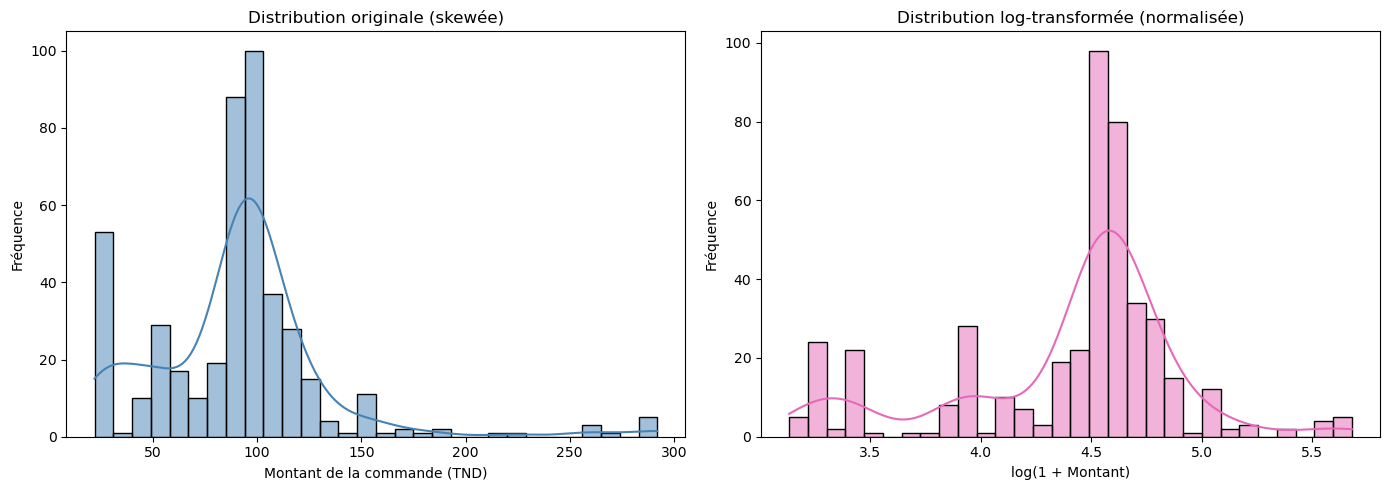


→ La transformation log1p réduit fortement le skewness
→ Le modèle apprendra mieux sur cette distribution normalisée


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

print('═' * 50)
print('  TARGET DIAGNOSTIC')
print('═' * 50)

target = df_reg['Montant_de_la_commande']
target_log = np.log1p(target)

print(target.describe())
print(f'\nSkewness (original) : {target.skew():.2f}')
print(f'Skewness (log1p)    : {target_log.skew():.2f}')

# ── Comparaison : Original vs Log-transformed ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(target, bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution originale (skewée)')
axes[0].set_xlabel('Montant de la commande (TND)')
axes[0].set_ylabel('Fréquence')

sns.histplot(target_log, bins=30, kde=True, ax=axes[1], color='#E669B9')
axes[1].set_title('Distribution log-transformée (normalisée)')
axes[1].set_xlabel('log(1 + Montant)')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

print('\n→ La transformation log1p réduit fortement le skewness')
print('→ Le modèle apprendra mieux sur cette distribution normalisée')


# Visualisation 

📊 Intervalles de prix :
Basse   : [21.95 → 86.00] TND
Moyenne : [86.00 → 100.00] TND
Chère   : [100.00 → 292.01] TND


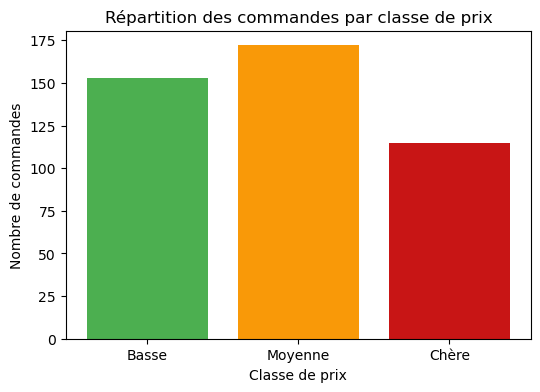

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Création TEMPORAIRE des 3 classes de prix (visualisation uniquement) ──
classe_prix_temp = pd.qcut(
    df_reg['Montant_de_la_commande'],
    q=3,
    labels=['Basse', 'Moyenne', 'Chère']
)

# ── Récupération des bornes (intervalles) ──────────────────
bins = pd.qcut(df_reg['Montant_de_la_commande'], q=3, retbins=True)[1]

print("📊 Intervalles de prix :")
print(f"Basse   : [{bins[0]:.2f} → {bins[1]:.2f}] TND")
print(f"Moyenne : [{bins[1]:.2f} → {bins[2]:.2f}] TND")
print(f"Chère   : [{bins[2]:.2f} → {bins[3]:.2f}] TND")

# ── Comptage des classes ───────────────────────────────────
counts = classe_prix_temp.value_counts().sort_index()

# ── Couleurs ───────────────────────────────────────────────
colors = ["#4CAF50", "#F99908", "#C81515"]

# ── Visualisation ───────────────────────────────────────────
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color=colors)

plt.title("Répartition des commandes par classe de prix")
plt.xlabel("Classe de prix")
plt.ylabel("Nombre de commandes")

plt.show()

# ⚠️ On ne garde PAS classe_prix dans df_reg
# C'est dérivé de la target → data leakage si inclus dans X
if "classe_prix" in df_reg.columns:
    df_reg = df_reg.drop(columns=["classe_prix"])
    print("✅ classe_prix supprimée de df_reg (éviter le data leakage)")



📊 Intervalles de prix :


<span style="color:#4CAF50">  Basse   : [18.00 → 85.00] TND </span>


<span style="color:#F99908">  Moyenne : [85.00 → 100.00] TND </span>


<span style="color:#C81515">  Chère   : [100.00 → 156.00] TND</span>

# Random Forest Regressor (with Log-Transform)


In [12]:
# ── Target ────────────────────────────────────────────────────
y = df_reg['Montant_de_la_commande']

# ── Colonnes à exclure ────────────────────────────────────────
# Numero_Commande : ID unique → le modèle mémorise au lieu d'apprendre
# Type_client     : toujours 'Particulier' (B2C only) → zéro variance
# type_vente      : toujours 'Site_Web' (B2C only)   → zéro variance
# classe_prix     : dérivée de la target              → data leakage

cols_to_drop = [
    'Montant_de_la_commande',   # target
    'Numero_Commande',           # ID unique
    'Type_client',               # single value
    'type_vente',                # single value
    'classe_prix',               # target leakage (au cas où)
]

X = df_reg.drop(columns=[c for c in cols_to_drop if c in df_reg.columns])

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"\nFeatures utilisées ({len(X.columns)}) :")
for col in X.columns:
    print(f"  - {col} ({X[col].dtype})")


X shape : (440, 18)
y shape : (440,)

Features utilisées (18) :
  - Quantite_totale (int64)
  - Prix_Unité_moyen (float64)
  - Montant_Remise (float64)
  - Montant_Livraison (float64)
  - a_code_promo (int64)
  - ville_client (object)
  - prix_catalogue (float64)
  - En_Promo (int64)
  - canal_produit (object)
  - categorie (object)
  - type_paiement (object)
  - Annee (int64)
  - Mois (int64)
  - Trimestre (object)
  - Semestre (object)
  - est_saison_haute (int64)
  - remise_pct (float64)
  - ratio_prix_catalogue (float64)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [14]:
print("X_train shape : "+str(X_train.shape)+" | X_test shape : "+str(X_test.shape))
print("y_train shape : "+str(y_train.shape)+" | y_test shape : "+str(y_test.shape))

X_train shape : (352, 18) | X_test shape : (88, 18)
y_train shape : (352,) | y_test shape : (88,)


In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# ── Colonnes ─────────────────────────────────────────
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

print('Num cols:', list(num_cols))
print('Cat cols:', list(cat_cols))

# ── Preprocessing ────────────────────────────────────
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# ── Pipeline interne ─────────────────────────────────
pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# ── TransformedTargetRegressor ────────────────────────
# Entraîne sur log1p(y), prédit en expm1(y_hat)
# Le .pkl sauvegardé inclura la transformation
# → regression.py n'a PAS besoin de changement
wrapped_rf = TransformedTargetRegressor(
    regressor=pipe_rf,
    func=np.log1p,
    inverse_func=np.expm1
)

# ── GridSearch ───────────────────────────────────────
params_rf = {
    'regressor__model__n_estimators': [100, 200, 300],
    'regressor__model__max_depth': [None, 10, 20],
    'regressor__model__min_samples_split': [2, 5],
}

grid_rf = GridSearchCV(
    wrapped_rf,
    params_rf,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print('── Random Forest + Log-Transform ──')
print('Meilleurs paramètres :', grid_rf.best_params_)
print('Meilleur score CV (MAE) :', round(-grid_rf.best_score_, 2))


Num cols: ['Quantite_totale', 'Prix_Unité_moyen', 'Montant_Remise', 'Montant_Livraison', 'a_code_promo', 'prix_catalogue', 'En_Promo', 'Annee', 'Mois', 'est_saison_haute', 'remise_pct', 'ratio_prix_catalogue']
Cat cols: ['ville_client', 'canal_produit', 'categorie', 'type_paiement', 'Trimestre', 'Semestre']
── Random Forest + Log-Transform ──
Meilleurs paramètres : {'regressor__model__max_depth': 20, 'regressor__model__min_samples_split': 2, 'regressor__model__n_estimators': 200}
Meilleur score CV (MAE) : 7.91


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ── Prédictions (déjà en échelle originale grâce au TransformedTargetRegressor)
y_pred_rf = grid_rf.best_estimator_.predict(X_test)

# ── Métriques ─────────────────────────────────────────────────
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) /
                          y_test.replace(0, np.nan))) * 100

print('══════════════════════════════════════')
print('  Random Forest + Log-Transform — Test')
print('══════════════════════════════════════')
print(f'  MAE   : {mae_rf:.2f}  TND')
print(f'  RMSE  : {rmse_rf:.2f} TND')
print(f'  R²    : {r2_rf:.4f}')
print(f'  MAPE  : {mape_rf:.2f} %')
print('══════════════════════════════════════')
print(f'\nInterprétation :')
print(f'  → En moyenne, le modèle se trompe de {mae_rf:.0f} TND par commande')
print(f'  → Il explique {r2_rf*100:.1f}% de la variance')
print(f'  → Plage prédite : [{y_pred_rf.min():.0f} – {y_pred_rf.max():.0f}] TND')


══════════════════════════════════════
  Random Forest + Log-Transform — Test
══════════════════════════════════════
  MAE   : 3.59  TND
  RMSE  : 8.52 TND
  R²    : 0.9233
  MAPE  : 7.01 %
══════════════════════════════════════

Interprétation :
  → En moyenne, le modèle se trompe de 4 TND par commande
  → Il explique 92.3% de la variance
  → Plage prédite : [23 – 123] TND


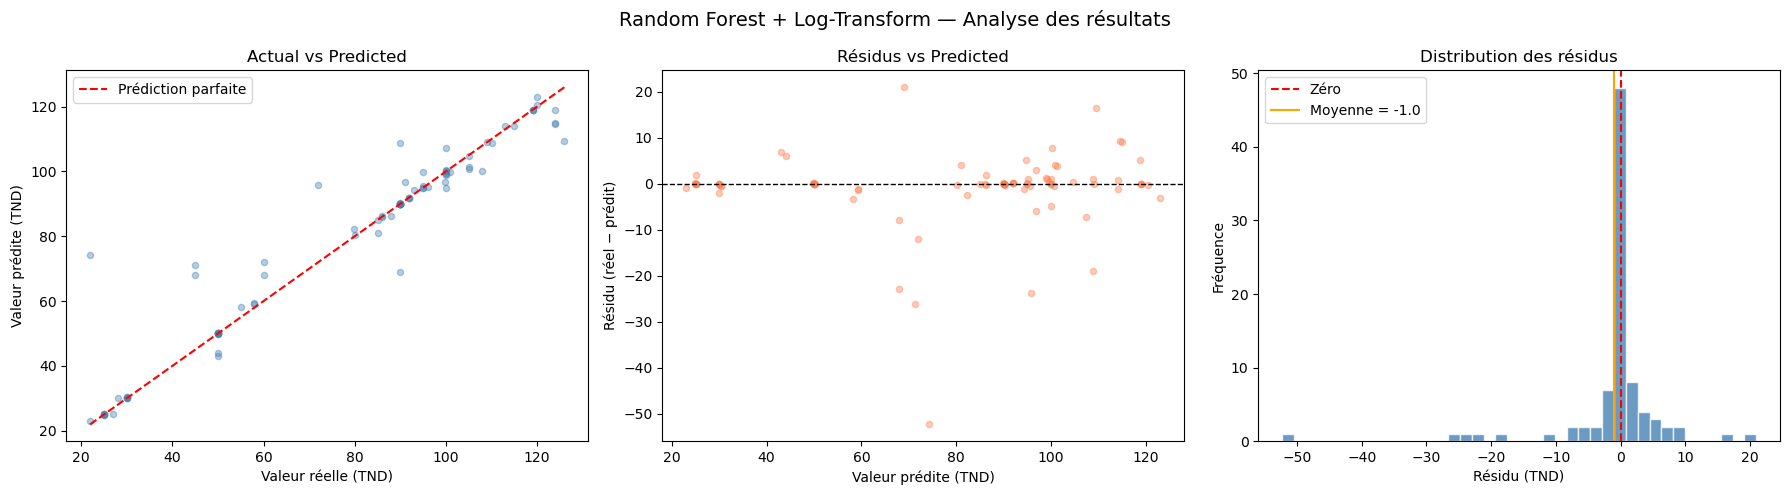

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Random Forest + Log-Transform — Analyse des résultats', fontsize=14)

# ── 1. Actual vs Predicted ────────────────────────────────────
ax = axes[0]
ax.scatter(y_test, y_pred_rf, alpha=0.4, color='steelblue', s=20)
lims = [min(y_test.min(), y_pred_rf.min()),
        max(y_test.max(), y_pred_rf.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
ax.set_xlabel('Valeur réelle (TND)')
ax.set_ylabel('Valeur prédite (TND)')
ax.set_title('Actual vs Predicted')
ax.legend()

# ── 2. Résidus vs Predicted ───────────────────────────────────
ax = axes[1]
residus = y_test - y_pred_rf
ax.scatter(y_pred_rf, residus, alpha=0.4, color='coral', s=20)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Valeur prédite (TND)')
ax.set_ylabel('Résidu (réel − prédit)')
ax.set_title('Résidus vs Predicted')

# ── 3. Distribution des résidus ───────────────────────────────
ax = axes[2]
ax.hist(residus, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0,            color='red',    linestyle='--', label='Zéro')
ax.axvline(residus.mean(), color='orange', linestyle='-',
           label=f'Moyenne = {residus.mean():.1f}')
ax.set_xlabel('Résidu (TND)')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution des résidus')
ax.legend()

plt.tight_layout()
plt.savefig('rf_regression_results.png', dpi=150)
plt.show()


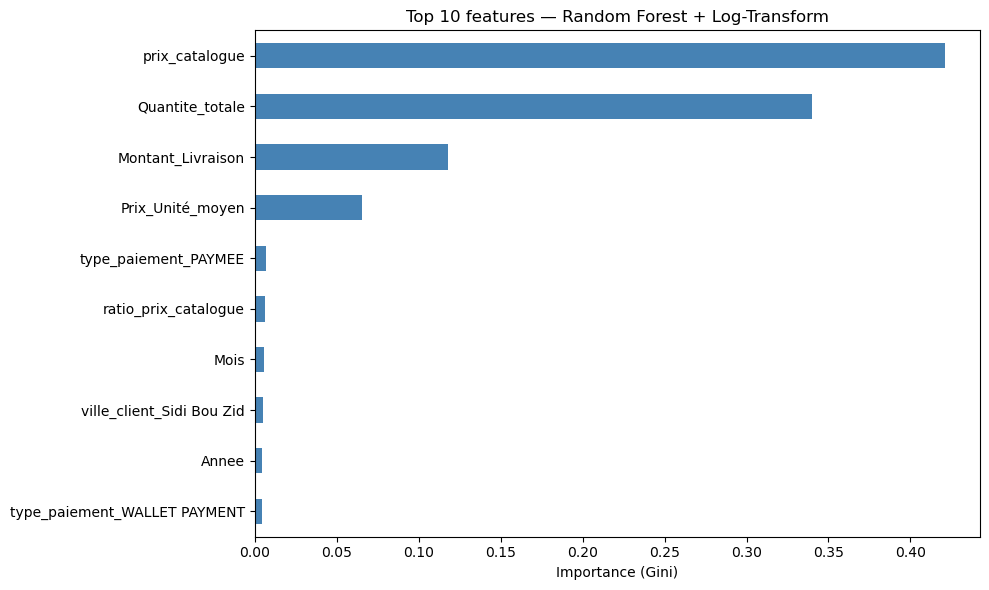


Top 10 features :
prix_catalogue                  0.4214
Quantite_totale                 0.3400
Montant_Livraison               0.1177
Prix_Unité_moyen                0.0654
type_paiement_PAYMEE            0.0068
ratio_prix_catalogue            0.0060
Mois                            0.0054
ville_client_Sidi Bou Zid       0.0052
Annee                           0.0045
type_paiement_WALLET PAYMENT    0.0044


In [18]:
# ── Feature Importance via TransformedTargetRegressor ────────
inner_pipe = grid_rf.best_estimator_.regressor_
rf_model   = inner_pipe.named_steps['model']
prep       = inner_pipe.named_steps['prep']

# Noms des features après OneHotEncoding
cat_feature_names = (prep
    .named_transformers_['cat']
    .get_feature_names_out(cat_cols)
    .tolist())
all_feature_names = list(num_cols) + cat_feature_names

# ── Top 10 features ───────────────────────────────────────────
importances = pd.Series(rf_model.feature_importances_,
                        index=all_feature_names).nlargest(10)

fig, ax = plt.subplots(figsize=(10, 6))
importances.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 features — Random Forest + Log-Transform')
ax.set_xlabel('Importance (Gini)')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()

print('\nTop 10 features :')
print(importances.round(4).to_string())


# Gradient Boosting Regressor (with Log-Transform)


In [19]:
from sklearn.ensemble import GradientBoostingRegressor

# ── Pipeline GBR ──────────────────────────────────────────────
pipe_gbr = Pipeline([
    ('prep',  preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

# ── Wrap avec log-transform ───────────────────────────────────
wrapped_gbr = TransformedTargetRegressor(
    regressor=pipe_gbr,
    func=np.log1p,
    inverse_func=np.expm1
)

params_gbr = {
    'regressor__model__n_estimators': [100, 200, 300],
    'regressor__model__max_depth': [3, 5, 7],
    'regressor__model__learning_rate': [0.05, 0.1, 0.2],
    'regressor__model__min_samples_split': [2, 5],
}

grid_gbr = GridSearchCV(
    wrapped_gbr, params_gbr,
    cv=5, scoring='neg_mean_absolute_error',
    n_jobs=-1
)
grid_gbr.fit(X_train, y_train)

y_pred_gbr = grid_gbr.best_estimator_.predict(X_test)

print('── Gradient Boosting + Log-Transform ──')
print('Meilleurs paramètres :', grid_gbr.best_params_)
print('Meilleur score CV (MAE) :', round(-grid_gbr.best_score_, 2))


── Gradient Boosting + Log-Transform ──
Meilleurs paramètres : {'regressor__model__learning_rate': 0.1, 'regressor__model__max_depth': 3, 'regressor__model__min_samples_split': 2, 'regressor__model__n_estimators': 300}
Meilleur score CV (MAE) : 6.07


# Evaluation Metrics — Gradient Boosting


In [20]:
mae_gbr  = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr   = r2_score(y_test, y_pred_gbr)
mape_gbr = np.mean(np.abs((y_test - y_pred_gbr) /
                           y_test.replace(0, np.nan))) * 100

print('══════════════════════════════════════')
print('  Gradient Boosting + Log — Test Set')
print('══════════════════════════════════════')
print(f'  MAE   : {mae_gbr:.2f}  TND')
print(f'  RMSE  : {rmse_gbr:.2f} TND')
print(f'  R²    : {r2_gbr:.4f}')
print(f'  MAPE  : {mape_gbr:.2f} %')
print('══════════════════════════════════════')


══════════════════════════════════════
  Gradient Boosting + Log — Test Set
══════════════════════════════════════
  MAE   : 3.05  TND
  RMSE  : 5.99 TND
  R²    : 0.9621
  MAPE  : 5.41 %
══════════════════════════════════════


# Comparaison des Modeles 

In [21]:
df_compare = pd.DataFrame([
    {
        'Modèle': 'Random Forest + Log',
        'MAE (TND)':  round(mae_rf,  2),
        'RMSE (TND)': round(rmse_rf, 2),
        'R²':         round(r2_rf,   4),
        'MAPE (%)':   round(mape_rf, 2),
        'CV MAE':     round(-grid_rf.best_score_, 2)
    },
    {
        'Modèle': 'Gradient Boosting + Log',
        'MAE (TND)':  round(mae_gbr,  2),
        'RMSE (TND)': round(rmse_gbr, 2),
        'R²':         round(r2_gbr,   4),
        'MAPE (%)':   round(mape_gbr, 2),
        'CV MAE':     round(-grid_gbr.best_score_, 2)
    }
]).sort_values('MAE (TND)')

print('\n══════════════════════════════════════════════════')
print('  Tableau comparatif — Modèles de régression')
print('══════════════════════════════════════════════════')
print(df_compare.to_string(index=False))

# Meilleur modèle
best_name = df_compare.iloc[0]['Modèle']
print(f'\n  Meilleur modèle : {best_name}')
print(f'  → MAE = {df_compare.iloc[0]["MAE (TND)"]} TND')
print(f'  → R²  = {df_compare.iloc[0]["R²"]}')

# Sélection automatique du meilleur
if df_compare.iloc[0]['Modèle'] == 'Random Forest + Log':
    best_grid = grid_rf
    print('\n→ Random Forest sélectionné pour la sauvegarde')
else:
    best_grid = grid_gbr
    print('\n→ Gradient Boosting sélectionné pour la sauvegarde')



══════════════════════════════════════════════════
  Tableau comparatif — Modèles de régression
══════════════════════════════════════════════════
                 Modèle  MAE (TND)  RMSE (TND)     R²  MAPE (%)  CV MAE
Gradient Boosting + Log       3.05        5.99 0.9621      5.41    6.07
    Random Forest + Log       3.59        8.52 0.9233      7.01    7.91

  Meilleur modèle : Gradient Boosting + Log
  → MAE = 3.05 TND
  → R²  = 0.9621

→ Gradient Boosting sélectionné pour la sauvegarde


In [22]:
# ── Vérification du meilleur modèle ─────────────────────────
best_model = best_grid.best_estimator_
inner = best_model.regressor_
prep_check = inner.named_steps['prep']

print(f'Type du modèle : {type(best_model).__name__}')
print(f'  → Regressor  : {type(inner.named_steps["model"]).__name__}')
print(f'  → Transform  : log1p / expm1')

for name, transformer, cols in prep_check.transformers_:
    print(f'\n--- {name} : {list(cols)} ---')
    if hasattr(transformer, 'categories_'):
        for i, cat in enumerate(transformer.categories_):
            print(f'  col {i} : {cat[:5]}')


Type du modèle : TransformedTargetRegressor
  → Regressor  : GradientBoostingRegressor
  → Transform  : log1p / expm1

--- num : ['Quantite_totale', 'Prix_Unité_moyen', 'Montant_Remise', 'Montant_Livraison', 'a_code_promo', 'prix_catalogue', 'En_Promo', 'Annee', 'Mois', 'est_saison_haute', 'remise_pct', 'ratio_prix_catalogue'] ---

--- cat : ['ville_client', 'canal_produit', 'categorie', 'type_paiement', 'Trimestre', 'Semestre'] ---
  col 0 : ['Ariana' 'Beja' 'Ben Arous' 'Bizerte' 'Gabes']
  col 1 : ['Site Web']
  col 2 : ['ART DE LA TABLE' 'ART DE TABLE' 'ARTICLES EN CUIVRE' 'ARTISANAT'
 "BOIS D'OLIVIER"]
  col 3 : ['AUTRE' 'CASH ON DELIVERY' 'PAY IN PERSON' 'PAYMEE' 'WALLET PAYMENT']
  col 4 : ['Trimestre 1' 'Trimestre 2' 'Trimestre 3' 'Trimestre 4']
  col 5 : ['Semestre 1' 'Semestre 2']


In [23]:
import joblib

# ── Sauvegarde du meilleur modèle ─────────────────────────
# Le TransformedTargetRegressor inclut la transformation log1p/expm1
# → regression.py n'a PAS besoin de changement
# → model.predict(X) retourne directement les valeurs en TND

joblib.dump(best_grid.best_estimator_, 'model_regression.pkl')
joblib.dump(list(X_train.columns),     'feature_columns_regression.pkl')

print('✅ Modèle sauvegardé : model_regression.pkl')
print('✅ Colonnes sauvegardées : feature_columns_regression.pkl')
print(f'\nType : {type(best_grid.best_estimator_).__name__}')
print(f'Transform : log1p(y) → train → expm1(pred)')
print(f'\nColonnes ({len(list(X_train.columns))}) :')
for col in X_train.columns:
    print(f'  - {col}')

# ── Test rapide ───────────────────────────────────────────
test_pred = best_grid.best_estimator_.predict(X_test[:3])
print(f'\n── Test rapide (3 premières lignes) ──')
for i, (real, pred) in enumerate(zip(y_test[:3], test_pred)):
    print(f'  Commande {i+1} : réel = {real:.2f} TND, prédit = {pred:.2f} TND')


✅ Modèle sauvegardé : model_regression.pkl
✅ Colonnes sauvegardées : feature_columns_regression.pkl

Type : TransformedTargetRegressor
Transform : log1p(y) → train → expm1(pred)

Colonnes (18) :
  - Quantite_totale
  - Prix_Unité_moyen
  - Montant_Remise
  - Montant_Livraison
  - a_code_promo
  - ville_client
  - prix_catalogue
  - En_Promo
  - canal_produit
  - categorie
  - type_paiement
  - Annee
  - Mois
  - Trimestre
  - Semestre
  - est_saison_haute
  - remise_pct
  - ratio_prix_catalogue

── Test rapide (3 premières lignes) ──
  Commande 1 : réel = 100.00 TND, prédit = 97.96 TND
  Commande 2 : réel = 50.00 TND, prédit = 44.47 TND
  Commande 3 : réel = 119.00 TND, prédit = 119.13 TND
